<a href="https://colab.research.google.com/github/pandeyayush260804/Phishing-system-minor/blob/main/Phishing_detection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# PhishGuard — URL Phishing Detection Model

This notebook trains and evaluates the URL phishing detection model for PhishGuard.

## Objective

Given a URL, predict whether it is:

- `0` → Legitimate
- `1` → Phishing

The model will eventually be exposed through an API and integrated with the existing PhishGuard URL Scanner.

## Workflow

1. Load and inspect the dataset
2. Clean the dataset
3. Analyze class distribution
4. Remove invalid/duplicate records
5. Analyze existing features
6. Build the URL feature pipeline
7. Split data without leakage
8. Train baseline models
9. Train candidate models
10. Compare evaluation metrics
11. Select and calibrate the final model
12. Test on unseen URLs
13. Save the model and feature extractor


In [6]:
!pip -q install pandas numpy scikit-learn xgboost matplotlib seaborn joblib tldextract

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import re
import os
import warnings

from urllib.parse import urlparse

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
    confusion_matrix
)

from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

warnings.filterwarnings("ignore")

print("Libraries loaded successfully.")

Libraries loaded successfully.


## 1. Upload Dataset

Upload the `urlset.csv` file provided for the PhishGuard URL detection model.

In [8]:
from google.colab import files

uploaded = files.upload()

print("Uploaded files:")
for filename in uploaded.keys():
    print("-", filename)

Saving urlset.csv to urlset (1).csv
Uploaded files:
- urlset (1).csv


In [9]:
file_path = list(uploaded.keys())[0]

df = pd.read_csv(
    file_path,
    encoding="latin1",
    on_bad_lines="skip",
    low_memory=False
)

print("First 5 rows:")
display(df.head())

print("\nDataset Information:")
df.info()

print("\nMissing Values:")
display(df.isnull().sum())

print("\nDuplicate Rows:", df.duplicated().sum())

First 5 rows:


,domain,ranking,mld_res,mld.ps_res,card_rem,ratio_Rrem,ratio_Arem,jaccard_RR,jaccard_RA,jaccard_AR,jaccard_AA,jaccard_ARrd,jaccard_ARrem,label
0,nobell.it/70ffb52d079109dca5664cce6f317373782/...,10000000,1.0,0.0,18.0,107.611111,107.277778,0.0,0.0,0.0,0.0,0.8,0.795729,1.0
1,www.dghjdgf.com/paypal.co.uk/cycgi-bin/webscrc...,10000000,0.0,0.0,11.0,150.636364,152.272727,0.0,0.0,0.0,0.0,0,0.768577,1.0
2,serviciosbys.com/paypal.cgi.bin.get-into.herf....,10000000,0.0,0.0,14.0,73.500000,72.642857,0.0,0.0,0.0,0.0,0,0.726582,1.0
3,mail.printakid.com/www.online.americanexpress....,10000000,0.0,0.0,6.0,562.000000,590.666667,0.0,0.0,0.0,0.0,0,0.85964,1.0
4,thewhiskeydregs.com/wp-content/themes/widescre...,10000000,0.0,0.0,8.0,29.000000,24.125000,0.0,0.0,0.0,0.0,0,0.748971,1.0



Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 96005 entries, 0 to 96004
Data columns (total 14 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   domain         96005 non-null  object 
 1   ranking        95953 non-null  object 
 2   mld_res        95935 non-null  object 
 3   mld.ps_res     95924 non-null  object 
 4   card_rem       95923 non-null  float64
 5   ratio_Rrem     95923 non-null  float64
 6   ratio_Arem     95923 non-null  float64
 7   jaccard_RR     95922 non-null  float64
 8   jaccard_RA     95921 non-null  float64
 9   jaccard_AR     95920 non-null  float64
 10  jaccard_AA     95919 non-null  float64
 11  jaccard_ARrd   95919 non-null  object 
 12  jaccard_ARrem  95917 non-null  object 
 13  label          95913 non-null  float64
dtypes: float64(8), object(6)
memory usage: 10.3+ MB

Missing Values:


,0
domain,0
ranking,52
mld_res,70
mld.ps_res,81
card_rem,82
ratio_Rrem,82
ratio_Arem,82
jaccard_RR,83
jaccard_RA,84
jaccard_AR,85



Duplicate Rows: 1


In [10]:

print("Label Distribution:")
print(df["label"].value_counts(dropna=False))

print("\nLabel Percentages:")
print(df["label"].value_counts(normalize=True, dropna=False) * 100)

Label Distribution:
label
0.0    48009
1.0    47904
NaN       92
Name: count, dtype: int64

Label Percentages:
label
0.0    50.006770
1.0    49.897401
NaN     0.095828
Name: proportion, dtype: float64


In [11]:
# CELL 8 — Inspect Label Values

print("Unique label values:")
print(df["label"].unique())

print("\nLabel data type:")
print(df["label"].dtype)

Unique label values:
[ 1. nan  0.]

Label data type:
float64


In [12]:
# CELL 9 — Clean Labels

# Convert label to numeric
df["label"] = pd.to_numeric(df["label"], errors="coerce")

# Remove rows where label is missing/invalid
before = len(df)

df = df.dropna(subset=["label"]).copy()

# Keep only binary labels
df = df[df["label"].isin([0, 1])].copy()

# Convert to integer
df["label"] = df["label"].astype(int)

after = len(df)

print("Rows before label cleaning:", before)
print("Rows after label cleaning:", after)
print("Rows removed:", before - after)

print("\nFinal label distribution:")
print(df["label"].value_counts())

Rows before label cleaning: 96005
Rows after label cleaning: 95913
Rows removed: 92

Final label distribution:
label
0    48009
1    47904
Name: count, dtype: int64


In [13]:
# CELL 10 — Remove Duplicate Rows
before = len(df)

df = df.drop_duplicates().copy()

after = len(df)

print("Rows before duplicate removal:", before)
print("Rows after duplicate removal:", after)
print("Duplicate rows removed:", before - after)

Rows before duplicate removal: 95913
Rows after duplicate removal: 95912
Duplicate rows removed: 1


In [14]:
# CELL 11 — Inspect URL Column

print("Domain/URL column type:")
print(df["domain"].dtype)

print("\nMissing URLs:")
print(df["domain"].isna().sum())

print("\nNumber of unique URLs:")
print(df["domain"].nunique())

print("\nSample URLs:")
for url in df["domain"].dropna().astype(str).head(10):
    print(url)

Domain/URL column type:
object

Missing URLs:
0

Number of unique URLs:
95911

Sample URLs:
nobell.it/70ffb52d079109dca5664cce6f317373782/login.SkyPe.com/en/cgi-bin/verification/login/70ffb52d079109dca5664cce6f317373/index.php?cmd=_profile-ach&outdated_page_tmpl=p/gen/failed-to-load&nav=0.5.1&login_access=1322408526
www.dghjdgf.com/paypal.co.uk/cycgi-bin/webscrcmd=_home-customer&nav=1/loading.php
serviciosbys.com/paypal.cgi.bin.get-into.herf.secure.dispatch35463256rzr321654641dsf654321874/href/href/href/secure/center/update/limit/seccure/4d7a1ff5c55825a2e632a679c2fd5353/
mail.printakid.com/www.online.americanexpress.com/index.html
thewhiskeydregs.com/wp-content/themes/widescreen/includes/temp/promocoessmiles/?84784787824HDJNDJDSJSHD//2724782784/
smilesvoegol.servebbs.org/voegol.php
premierpaymentprocessing.com/includes/boleto-2via-07-2012.php
myxxxcollection.com/v1/js/jih321/bpd.com.do/do/l.popular.php
super1000.info/docs
horizonsgallery.com/js/bin/ssl1/_id/www.paypal.com/fr/cgi-bin/we

In [15]:

# CELL 12 — Analyze Duplicate URLs
duplicate_urls = df["domain"].astype(str).duplicated().sum()

print("Duplicate URL records:", duplicate_urls)

print("\nURLs appearing multiple times:")
url_counts = df["domain"].astype(str).value_counts()

display(
    url_counts[url_counts > 1].head(20)
)

Duplicate URL records: 1

URLs appearing multiple times:


,count
domain,
'www.allegropl.xaa.pl/enter_login.html?session=OGY1YgQGXQALBwcxzvcxNYWgFVVgMPBgANAAcEAwMHDg1cUlEBAFNbDABQAwEHUlvcbcvxcgbcANzA5OA\%3D\%3D&amp;global_login_hash=1f0f47e7fcvxvvc8fb48f851c41eafvdgdg33a7&amp;session_login_hash=e4baf33efvdsfdsg6422224f66b652028fvcxfvde726&amp;url=N2NjOAwWQBYNTExZCAzxzdfvzgfhfgVgAAVxEMQElzBgFZEAdHSXMGAVkQB0dIRwsTFxYHRxZYDRBdIg1GCvdgdgcxzcszdfbgFRWZGI0Zg\%3D\%3D&amp;cod=OGZkcsVlNmcsk&amp;version=A',2


In [16]:
# CELL 13 — Existing Feature Data Types

feature_columns = [
    "ranking",
    "mld_res",
    "mld.ps_res",
    "card_rem",
    "ratio_Rrem",
    "ratio_Arem",
    "jaccard_RR",
    "jaccard_RA",
    "jaccard_AR",
    "jaccard_AA",
    "jaccard_ARrd",
    "jaccard_ARrem"
]

print("Feature data types:")
display(df[feature_columns].dtypes)

Feature data types:


,0
ranking,object
mld_res,object
mld.ps_res,object
card_rem,float64
ratio_Rrem,float64
ratio_Arem,float64
jaccard_RR,float64
jaccard_RA,float64
jaccard_AR,float64
jaccard_AA,float64


In [17]:
# CELL 14 — Check Numeric Conversion
for col in feature_columns:
    numeric_values = pd.to_numeric(df[col], errors="coerce")

    invalid_count = numeric_values.isna().sum()

    print(
        f"{col:15} | "
        f"original dtype: {str(df[col].dtype):8} | "
        f"invalid/missing numeric values: {invalid_count}"
    )

ranking         | original dtype: object   | invalid/missing numeric values: 1
mld_res         | original dtype: object   | invalid/missing numeric values: 0
mld.ps_res      | original dtype: object   | invalid/missing numeric values: 0
card_rem        | original dtype: float64  | invalid/missing numeric values: 0
ratio_Rrem      | original dtype: float64  | invalid/missing numeric values: 0
ratio_Arem      | original dtype: float64  | invalid/missing numeric values: 0
jaccard_RR      | original dtype: float64  | invalid/missing numeric values: 0
jaccard_RA      | original dtype: float64  | invalid/missing numeric values: 0
jaccard_AR      | original dtype: float64  | invalid/missing numeric values: 0
jaccard_AA      | original dtype: float64  | invalid/missing numeric values: 0
jaccard_ARrd    | original dtype: object   | invalid/missing numeric values: 0
jaccard_ARrem   | original dtype: object   | invalid/missing numeric values: 0


In [18]:
# CELL 15 — Feature Statistics
numeric_df = df[feature_columns].apply(
    pd.to_numeric,
    errors="coerce"
)

display(numeric_df.describe().T)

,count,mean,std,min,25%,50%,75%,max
ranking,95911.0,5.888741e+06,4.878412e+06,1.0,25471.000000,1.000000e+07,1.000000e+07,1.000000e+07
mld_res,95912.0,4.555947e-01,4.980269e-01,0.0,0.000000,0.000000e+00,1.000000e+00,1.000000e+00
mld.ps_res,95912.0,2.024460e-01,4.018250e-01,0.0,0.000000,0.000000e+00,0.000000e+00,1.000000e+00
card_rem,95912.0,4.573953e+00,4.343271e+00,0.0,2.000000,3.000000e+00,6.000000e+00,5.800000e+01
ratio_Rrem,95912.0,1.352620e+02,1.609930e+02,0.0,43.000000,1.040602e+02,1.741429e+02,5.507000e+03
ratio_Arem,95912.0,1.385539e+02,1.754850e+02,0.0,39.666667,1.033333e+02,1.783083e+02,6.097000e+03
jaccard_RR,95912.0,4.010512e-03,2.874719e-02,0.0,0.000000,0.000000e+00,0.000000e+00,1.000000e+00
jaccard_RA,95912.0,3.768879e-03,2.447854e-02,0.0,0.000000,0.000000e+00,0.000000e+00,9.166670e-01
jaccard_AR,95912.0,3.367646e-03,2.379487e-02,0.0,0.000000,0.000000e+00,0.000000e+00,1.000000e+00
jaccard_AA,95912.0,3.644617e-03,2.825983e-02,0.0,0.000000,0.000000e+00,0.000000e+00,1.000000e+00


In [19]:
# CELL 16 — Feature Missing Values

missing_features = numeric_df.isnull().sum()

missing_summary = pd.DataFrame({
    "missing_count": missing_features,
    "missing_percentage": (
        missing_features / len(df) * 100
    )
})

display(missing_summary)

,missing_count,missing_percentage
ranking,1,0.001043
mld_res,0,0.000000
mld.ps_res,0,0.000000
card_rem,0,0.000000
ratio_Rrem,0,0.000000
ratio_Arem,0,0.000000
jaccard_RR,0,0.000000
jaccard_RA,0,0.000000
jaccard_AR,0,0.000000
jaccard_AA,0,0.000000


In [20]:
# ============================================================
# CELL 17 — URL FEATURE EXTRACTOR
# ============================================================

import math
import ipaddress
from urllib.parse import urlparse

SUSPICIOUS_WORDS = [
    "login",
    "signin",
    "sign-in",
    "verify",
    "verification",
    "account",
    "update",
    "secure",
    "security",
    "confirm",
    "confirmation",
    "password",
    "passwd",
    "credential",
    "authenticate",
    "authentication",
    "bank",
    "banking",
    "wallet",
    "payment",
    "billing",
    "invoice",
    "recover",
    "recovery",
    "unlock",
    "alert",
    "suspended",
    "urgent",
    "paypal",
    "microsoft",
    "apple",
    "google"
]

SHORTENING_SERVICES = [
    "bit.ly",
    "tinyurl.com",
    "t.co",
    "goo.gl",
    "ow.ly",
    "is.gd",
    "buff.ly",
    "cutt.ly",
    "rb.gy",
    "shorturl.at"
]


def calculate_entropy(text):
    if not text:
        return 0.0

    probabilities = [
        text.count(char) / len(text)
        for char in set(text)
    ]

    return -sum(
        p * math.log2(p)
        for p in probabilities
        if p > 0
    )


def has_ip_address(hostname):
    if not hostname:
        return 0

    try:
        ipaddress.ip_address(hostname)
        return 1
    except ValueError:
        return 0


def extract_url_features(url):

    url = str(url).strip()

    parsed = urlparse(
        url if "://" in url else "http://" + url
    )

    hostname = parsed.hostname or ""
    path = parsed.path or ""
    query = parsed.query or ""
    fragment = parsed.fragment or ""

    hostname_lower = hostname.lower()
    url_lower = url.lower()

    digits = sum(c.isdigit() for c in url)
    letters = sum(c.isalpha() for c in url)

    special_chars = sum(
        not c.isalnum()
        for c in url
    )

    subdomain_count = max(
        0,
        len(hostname_lower.split(".")) - 2
    )

    suspicious_word_count = sum(
        1
        for word in SUSPICIOUS_WORDS
        if word in url_lower
    )

    uses_shortener = int(
        any(
            service in hostname_lower
            for service in SHORTENING_SERVICES
        )
    )

    uses_https = int(
        parsed.scheme.lower() == "https"
    )

    has_at_symbol = int("@" in url)

    double_slash = int("//" in path)

    has_punycode = int(
        "xn--" in hostname_lower
    )

    hostname_hyphens = hostname.count("-")

    hostname_digits = sum(
        c.isdigit()
        for c in hostname
    )

    features = {

        # URL length / structure
        "url_length": len(url),
        "hostname_length": len(hostname),
        "path_length": len(path),
        "query_length": len(query),
        "fragment_length": len(fragment),

        # Character counts
        "digit_count": digits,
        "letter_count": letters,
        "special_char_count": special_chars,

        # URL symbols
        "dot_count": url.count("."),
        "hyphen_count": url.count("-"),
        "slash_count": url.count("/"),
        "question_count": url.count("?"),
        "equals_count": url.count("="),
        "ampersand_count": url.count("&"),
        "percent_count": url.count("%"),
        "at_count": url.count("@"),
        "underscore_count": url.count("_"),

        # Hostname
        "subdomain_count": subdomain_count,
        "hostname_hyphens": hostname_hyphens,
        "hostname_digits": hostname_digits,

        # Security indicators
        "uses_https": uses_https,
        "has_ip_address": has_ip_address(hostname),
        "has_at_symbol": has_at_symbol,
        "has_double_slash": double_slash,
        "has_punycode": has_punycode,
        "uses_shortener": uses_shortener,
        "suspicious_word_count": suspicious_word_count,

        # Entropy
        "url_entropy": calculate_entropy(url),
        "hostname_entropy": calculate_entropy(hostname),

        # Ratios
        "digit_ratio": digits / max(len(url), 1),
        "letter_ratio": letters / max(len(url), 1),
        "special_char_ratio": special_chars / max(len(url), 1)
    }

    return features


print("URL feature extractor created successfully.")
print("Number of features:", len(extract_url_features("https://example.com")))

URL feature extractor created successfully.
Number of features: 32


In [21]:
# ============================================================
# CELL 18 — TEST URL FEATURE EXTRACTOR
# ============================================================

test_urls = [
    "https://www.google.com",
    "https://www.amazon.in",
    "http://192.168.1.1/login",
    "http://secure-login-account-verify.com/user/password",
    "https://bit.ly/example"
]

for url in test_urls:

    features = extract_url_features(url)

    print("\nURL:")
    print(url)

    print("\nExtracted Features:")

    for key, value in features.items():
        print(f"{key:25} : {value}")

    print("-" * 70)


URL:
https://www.google.com

Extracted Features:
url_length                : 22
hostname_length           : 14
path_length               : 0
query_length              : 0
fragment_length           : 0
digit_count               : 0
letter_count              : 17
special_char_count        : 5
dot_count                 : 2
hyphen_count              : 0
slash_count               : 2
question_count            : 0
equals_count              : 0
ampersand_count           : 0
percent_count             : 0
at_count                  : 0
underscore_count          : 0
subdomain_count           : 1
hostname_hyphens          : 0
hostname_digits           : 0
uses_https                : 1
has_ip_address            : 0
has_at_symbol             : 0
has_double_slash          : 0
has_punycode              : 0
uses_shortener            : 0
suspicious_word_count     : 1
url_entropy               : 3.6635327548042547
hostname_entropy          : 2.8423709931771084
digit_ratio               : 0.0
letter_rati

In [22]:
# ============================================================
# CELL 19 — GENERATE FEATURES FOR ENTIRE DATASET
# ============================================================

print("Extracting features from URLs...")

feature_records = [
    extract_url_features(url)
    for url in df["domain"]
]

X = pd.DataFrame(feature_records)

y = df["label"].copy().reset_index(drop=True)

X = X.reset_index(drop=True)

print("\nFeature extraction completed.")

print("X shape:", X.shape)
print("y shape:", y.shape)

print("\nFeature columns:")
print(X.columns.tolist())

Extracting features from URLs...

Feature extraction completed.
X shape: (95912, 32)
y shape: (95912,)

Feature columns:
['url_length', 'hostname_length', 'path_length', 'query_length', 'fragment_length', 'digit_count', 'letter_count', 'special_char_count', 'dot_count', 'hyphen_count', 'slash_count', 'question_count', 'equals_count', 'ampersand_count', 'percent_count', 'at_count', 'underscore_count', 'subdomain_count', 'hostname_hyphens', 'hostname_digits', 'uses_https', 'has_ip_address', 'has_at_symbol', 'has_double_slash', 'has_punycode', 'uses_shortener', 'suspicious_word_count', 'url_entropy', 'hostname_entropy', 'digit_ratio', 'letter_ratio', 'special_char_ratio']


In [23]:
# ============================================================
# CELL 20 — FEATURE QUALITY CHECK
# ============================================================

print("Missing values:")
print(X.isnull().sum().sum())

print("\nInfinite values:")
print(
    np.isinf(
        X.select_dtypes(include=np.number)
    ).sum().sum()
)

print("\nData types:")
print(X.dtypes.value_counts())

print("\nFeature statistics:")
display(X.describe().T)

Missing values:
0

Infinite values:
0

Data types:
int64      27
float64     5
Name: count, dtype: int64

Feature statistics:


,count,mean,std,min,25%,50%,75%,max
url_length,95912.0,64.457430,64.940232,9.000000,30.000000,42.000000,71.000000,2175.000000
hostname_length,95912.0,22.345233,23.390145,0.000000,14.000000,17.000000,22.000000,248.000000
path_length,95912.0,25.838164,26.017472,0.000000,11.000000,19.000000,33.000000,2156.000000
query_length,95912.0,15.934148,48.813914,0.000000,0.000000,0.000000,0.000000,1111.000000
fragment_length,95912.0,0.084619,3.031823,0.000000,0.000000,0.000000,0.000000,271.000000
digit_count,95912.0,8.168279,19.403323,0.000000,0.000000,1.000000,5.000000,286.000000
letter_count,95912.0,47.578562,44.928884,2.000000,24.000000,34.000000,53.000000,2141.000000
special_char_count,95912.0,8.710547,7.289531,2.000000,4.000000,6.000000,10.000000,209.000000
dot_count,95912.0,3.268944,2.330287,0.000000,2.000000,3.000000,3.000000,37.000000
hyphen_count,95912.0,0.655538,1.517971,0.000000,0.000000,0.000000,1.000000,36.000000


In [24]:
# ============================================================
# CELL 21 — FEATURE / TARGET CORRELATION
# ============================================================

analysis_df = X.copy()

analysis_df["label"] = y.values

correlations = (
    analysis_df
    .corr(numeric_only=True)["label"]
    .drop("label")
    .sort_values(
        key=abs,
        ascending=False
    )
)

print("Features most associated with phishing:")

display(
    correlations
    .to_frame("correlation")
    .head(15)
)

Features most associated with phishing:


,correlation
suspicious_word_count,0.486506
url_entropy,0.452747
url_length,0.426302
special_char_count,0.411330
letter_count,0.401578
question_count,0.352406
digit_count,0.342378
equals_count,0.318795
hostname_entropy,0.314450
digit_ratio,0.308797


In [25]:
# ============================================================
# CELL 22 — COMPARE FEATURE MEANS
# ============================================================

comparison = X.copy()

comparison["label"] = y.values

mean_comparison = (
    comparison
    .groupby("label")
    .mean()
    .T
)

mean_comparison.columns = [
    "Legitimate (0)",
    "Phishing (1)"
]

mean_comparison["Difference"] = (
    mean_comparison["Phishing (1)"]
    - mean_comparison["Legitimate (0)"]
)

display(
    mean_comparison
    .sort_values(
        "Difference",
        key=abs,
        ascending=False
    )
    .head(20)
)

,Legitimate (0),Phishing (1),Difference
url_length,36.803995,92.172056,55.368061
letter_count,29.556146,65.640858,36.084712
query_length,0.893541,31.008037,30.114496
path_length,19.128934,32.562240,13.433306
digit_count,1.532379,14.818863,13.286484
hostname_length,16.674040,28.028975,11.354935
special_char_count,5.715470,11.712252,5.996782
hostname_digits,0.071799,3.253888,3.182089
dot_count,2.624883,3.914431,1.289548
slash_count,2.377346,3.574494,1.197148


In [26]:
# ============================================================
# CELL 23 — REMOVE DUPLICATE URLS
# ============================================================

training_df = pd.DataFrame({
    "url": df["domain"].values,
    "label": y.values
})

before = len(training_df)

training_df = training_df.drop_duplicates(
    subset=["url"],
    keep="first"
).reset_index(drop=True)

after = len(training_df)

print("Rows before duplicate URL removal:", before)
print("Rows after duplicate URL removal:", after)
print("Duplicate URLs removed:", before - after)

Rows before duplicate URL removal: 95912
Rows after duplicate URL removal: 95911
Duplicate URLs removed: 1


In [27]:
# ============================================================
# CELL 24 — REBUILD X AND y
# ============================================================

X = pd.DataFrame([
    extract_url_features(url)
    for url in training_df["url"]
])

y = training_df["label"]

print("X shape:", X.shape)
print("y shape:", y.shape)

print("\nClass distribution:")
print(y.value_counts())

print("\nClass percentages:")
print(y.value_counts(normalize=True) * 100)

X shape: (95911, 32)
y shape: (95911,)

Class distribution:
label
0    48009
1    47902
Name: count, dtype: int64

Class percentages:
label
0    50.055781
1    49.944219
Name: proportion, dtype: float64


In [28]:
# ============================================================
# CELL 25 — TRAIN / VALIDATION / TEST SPLIT
# ============================================================

# First: 70% train, 30% temporary
X_train, X_temp, y_train, y_temp = train_test_split(
    X,
    y,
    test_size=0.30,
    random_state=42,
    stratify=y
)

# Second: split temporary into 15% validation and 15% test
X_val, X_test, y_val, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=0.50,
    random_state=42,
    stratify=y_temp
)

print("Training set:")
print(X_train.shape)

print("\nValidation set:")
print(X_val.shape)

print("\nTest set:")
print(X_test.shape)

print("\nClass distribution:")
print("Train:")
print(y_train.value_counts(normalize=True))

print("\nValidation:")
print(y_val.value_counts(normalize=True))

print("\nTest:")
print(y_test.value_counts(normalize=True))

Training set:
(67137, 32)

Validation set:
(14387, 32)

Test set:
(14387, 32)

Class distribution:
Train:
label
0    0.500559
1    0.499441
Name: proportion, dtype: float64

Validation:
label
0    0.500521
1    0.499479
Name: proportion, dtype: float64

Test:
label
0    0.500591
1    0.499409
Name: proportion, dtype: float64


In [29]:
# ============================================================
# CELL 26 — RANDOM FOREST BASELINE
# ============================================================

print("Training Random Forest...")

rf_model = RandomForestClassifier(
    n_estimators=300,
    max_depth=None,
    min_samples_split=2,
    min_samples_leaf=1,
    random_state=42,
    n_jobs=-1,
    class_weight="balanced"
)

rf_model.fit(X_train, y_train)

print("Random Forest training completed.")

Training Random Forest...
Random Forest training completed.


In [30]:
# ============================================================
# CELL 27 — RANDOM FOREST VALIDATION
# ============================================================

rf_val_predictions = rf_model.predict(X_val)
rf_val_probabilities = rf_model.predict_proba(X_val)[:, 1]

rf_accuracy = accuracy_score(
    y_val,
    rf_val_predictions
)

rf_precision = precision_score(
    y_val,
    rf_val_predictions
)

rf_recall = recall_score(
    y_val,
    rf_val_predictions
)

rf_f1 = f1_score(
    y_val,
    rf_val_predictions
)

rf_roc_auc = roc_auc_score(
    y_val,
    rf_val_probabilities
)

print("Random Forest — Validation Results")
print("=" * 50)

print(f"Accuracy : {rf_accuracy:.4f}")
print(f"Precision: {rf_precision:.4f}")
print(f"Recall   : {rf_recall:.4f}")
print(f"F1 Score : {rf_f1:.4f}")
print(f"ROC-AUC  : {rf_roc_auc:.4f}")

print("\nClassification Report:")
print(
    classification_report(
        y_val,
        rf_val_predictions,
        target_names=["Legitimate", "Phishing"]
    )
)

Random Forest — Validation Results
Accuracy : 0.9224
Precision: 0.9463
Recall   : 0.8954
F1 Score : 0.9201
ROC-AUC  : 0.9726

Classification Report:
              precision    recall  f1-score   support

  Legitimate       0.90      0.95      0.92      7201
    Phishing       0.95      0.90      0.92      7186

    accuracy                           0.92     14387
   macro avg       0.92      0.92      0.92     14387
weighted avg       0.92      0.92      0.92     14387



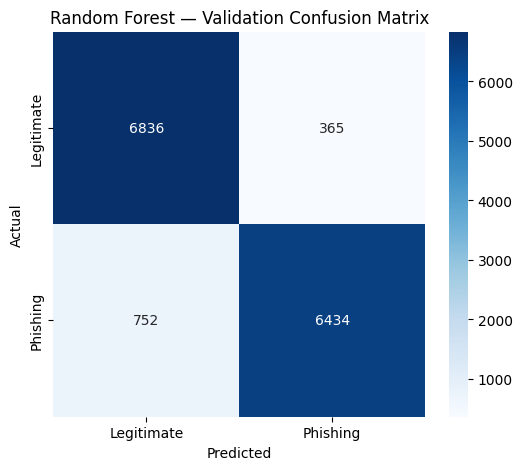

In [31]:
# ============================================================
# CELL 28 — RANDOM FOREST CONFUSION MATRIX
# ============================================================

rf_cm = confusion_matrix(
    y_val,
    rf_val_predictions
)

plt.figure(figsize=(6, 5))

sns.heatmap(
    rf_cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Legitimate", "Phishing"],
    yticklabels=["Legitimate", "Phishing"]
)

plt.title("Random Forest — Validation Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [32]:
# ============================================================
# CELL 29 — XGBOOST MODEL
# ============================================================

print("Training XGBoost...")

xgb_model = XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="binary:logistic",
    eval_metric="logloss",
    random_state=42,
    n_jobs=-1
)

xgb_model.fit(
    X_train,
    y_train
)

print("XGBoost training completed.")

Training XGBoost...
XGBoost training completed.


In [33]:
# ============================================================
# CELL 30 — XGBOOST VALIDATION
# ============================================================

xgb_val_predictions = xgb_model.predict(X_val)

xgb_val_probabilities = (
    xgb_model.predict_proba(X_val)[:, 1]
)

xgb_accuracy = accuracy_score(
    y_val,
    xgb_val_predictions
)

xgb_precision = precision_score(
    y_val,
    xgb_val_predictions
)

xgb_recall = recall_score(
    y_val,
    xgb_val_predictions
)

xgb_f1 = f1_score(
    y_val,
    xgb_val_predictions
)

xgb_roc_auc = roc_auc_score(
    y_val,
    xgb_val_probabilities
)

print("XGBoost — Validation Results")
print("=" * 50)

print(f"Accuracy : {xgb_accuracy:.4f}")
print(f"Precision: {xgb_precision:.4f}")
print(f"Recall   : {xgb_recall:.4f}")
print(f"F1 Score : {xgb_f1:.4f}")
print(f"ROC-AUC  : {xgb_roc_auc:.4f}")

print("\nClassification Report:")

print(
    classification_report(
        y_val,
        xgb_val_predictions,
        target_names=["Legitimate", "Phishing"]
    )
)

XGBoost — Validation Results
Accuracy : 0.9211
Precision: 0.9550
Recall   : 0.8837
F1 Score : 0.9180
ROC-AUC  : 0.9727

Classification Report:
              precision    recall  f1-score   support

  Legitimate       0.89      0.96      0.92      7201
    Phishing       0.96      0.88      0.92      7186

    accuracy                           0.92     14387
   macro avg       0.92      0.92      0.92     14387
weighted avg       0.92      0.92      0.92     14387



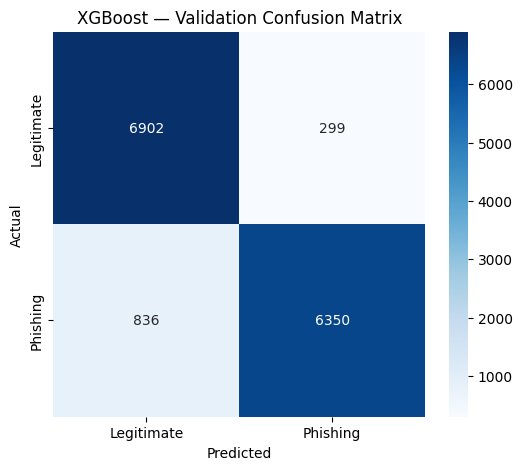

In [34]:
# ============================================================
# CELL 31 — XGBOOST CONFUSION MATRIX
# ============================================================

xgb_cm = confusion_matrix(
    y_val,
    xgb_val_predictions
)

plt.figure(figsize=(6, 5))

sns.heatmap(
    xgb_cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Legitimate", "Phishing"],
    yticklabels=["Legitimate", "Phishing"]
)

plt.title("XGBoost — Validation Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

In [35]:
# ============================================================
# CELL 32 — MODEL COMPARISON
# ============================================================

model_comparison = pd.DataFrame({

    "Model": [
        "Random Forest",
        "XGBoost"
    ],

    "Accuracy": [
        rf_accuracy,
        xgb_accuracy
    ],

    "Precision": [
        rf_precision,
        xgb_precision
    ],

    "Recall": [
        rf_recall,
        xgb_recall
    ],

    "F1 Score": [
        rf_f1,
        xgb_f1
    ],

    "ROC-AUC": [
        rf_roc_auc,
        xgb_roc_auc
    ]
})

display(
    model_comparison
    .sort_values(
        "F1 Score",
        ascending=False
    )
)

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Random Forest,0.922360,0.946316,0.895352,0.920129,0.972617
1,XGBoost,0.921109,0.955031,0.883663,0.917962,0.972713


In [36]:
# ============================================================
# CELL 33 — PRECISION-RECALL AUC
# ============================================================

from sklearn.metrics import average_precision_score

rf_pr_auc = average_precision_score(
    y_val,
    rf_val_probabilities
)

xgb_pr_auc = average_precision_score(
    y_val,
    xgb_val_probabilities
)

print("Precision-Recall AUC")
print("=" * 40)

print(f"Random Forest PR-AUC : {rf_pr_auc:.4f}")
print(f"XGBoost PR-AUC       : {xgb_pr_auc:.4f}")

Precision-Recall AUC
Random Forest PR-AUC : 0.9778
XGBoost PR-AUC       : 0.9779


In [37]:
# ============================================================
# CELL 34 — COMPLETE MODEL COMPARISON
# ============================================================

model_comparison = pd.DataFrame({

    "Model": [
        "Random Forest",
        "XGBoost"
    ],

    "Accuracy": [
        rf_accuracy,
        xgb_accuracy
    ],

    "Precision": [
        rf_precision,
        xgb_precision
    ],

    "Recall": [
        rf_recall,
        xgb_recall
    ],

    "F1 Score": [
        rf_f1,
        xgb_f1
    ],

    "ROC-AUC": [
        rf_roc_auc,
        xgb_roc_auc
    ],

    "PR-AUC": [
        rf_pr_auc,
        xgb_pr_auc
    ]
})

display(
    model_comparison.sort_values(
        "F1 Score",
        ascending=False
    )
)

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC,PR-AUC
0,Random Forest,0.922360,0.946316,0.895352,0.920129,0.972617,0.977768
1,XGBoost,0.921109,0.955031,0.883663,0.917962,0.972713,0.977930


In [38]:
# ============================================================
# CELL 35 — RANDOM FOREST FEATURE IMPORTANCE
# ============================================================

feature_importance = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": rf_model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    "Importance",
    ascending=False
)

print("Top URL features used by Random Forest:")

display(
    feature_importance.head(20)
)

Top URL features used by Random Forest:


,Feature,Importance
26,suspicious_word_count,0.107786
0,url_length,0.103039
17,subdomain_count,0.095634
6,letter_count,0.081375
2,path_length,0.077924
27,url_entropy,0.071444
28,hostname_entropy,0.065459
1,hostname_length,0.054464
7,special_char_count,0.047858
5,digit_count,0.043327


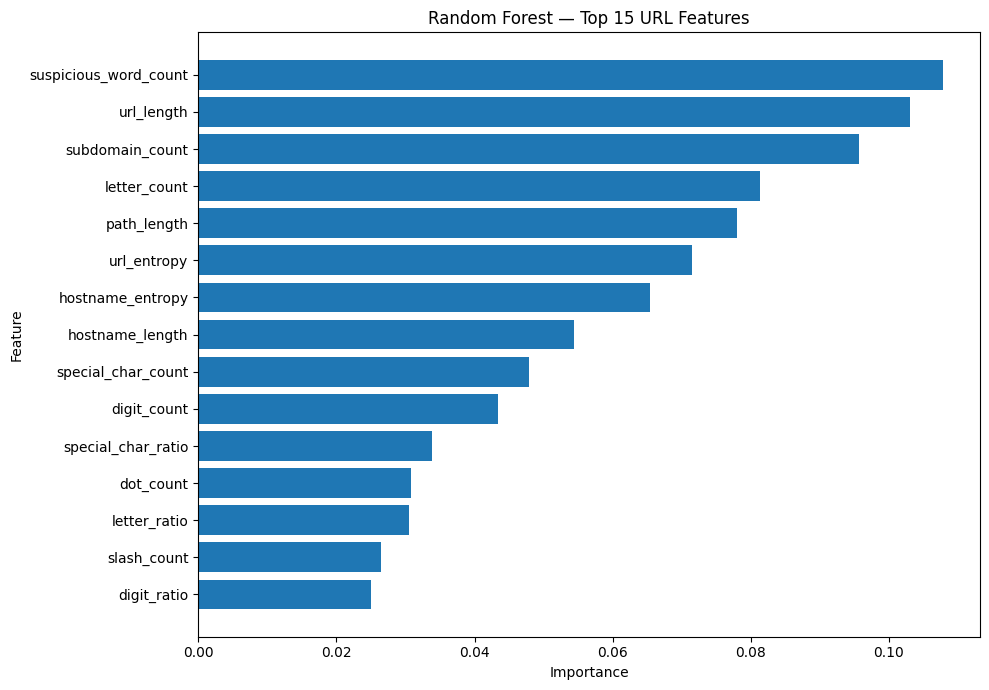

In [39]:
# ============================================================
# CELL 36 — FEATURE IMPORTANCE VISUALIZATION
# ============================================================

top_features = feature_importance.head(15).sort_values(
    "Importance"
)

plt.figure(figsize=(10, 7))

plt.barh(
    top_features["Feature"],
    top_features["Importance"]
)

plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Random Forest — Top 15 URL Features")

plt.tight_layout()
plt.show()

In [40]:
# ============================================================
# CELL 37 — THRESHOLD ANALYSIS
# ============================================================

threshold_results = []

for threshold in np.arange(0.10, 0.91, 0.05):

    predictions = (
        rf_val_probabilities >= threshold
    ).astype(int)

    precision = precision_score(
        y_val,
        predictions,
        zero_division=0
    )

    recall = recall_score(
        y_val,
        predictions,
        zero_division=0
    )

    f1 = f1_score(
        y_val,
        predictions,
        zero_division=0
    )

    threshold_results.append({
        "Threshold": round(threshold, 2),
        "Precision": precision,
        "Recall": recall,
        "F1": f1
    })

threshold_df = pd.DataFrame(threshold_results)

display(threshold_df)

,Threshold,Precision,Recall,F1
0,0.10,0.729197,0.978013,0.835473
1,0.15,0.780521,0.967993,0.864207
2,0.20,0.818690,0.958252,0.882990
3,0.25,0.851162,0.947815,0.896892
4,0.30,0.880141,0.938074,0.908185
5,0.35,0.900189,0.927498,0.913639
6,0.40,0.918094,0.917200,0.917647
7,0.45,0.933095,0.906346,0.919526
8,0.50,0.946316,0.895352,0.920129
9,0.55,0.958396,0.881575,0.918382


In [41]:
# ============================================================
# CELL 38 — BEST F1 THRESHOLD
# ============================================================

best_f1_row = threshold_df.loc[
    threshold_df["F1"].idxmax()
]

print("Best threshold based on F1:")
print("=" * 40)

print(
    f"Threshold : {best_f1_row['Threshold']:.2f}"
)

print(
    f"Precision : {best_f1_row['Precision']:.4f}"
)

print(
    f"Recall    : {best_f1_row['Recall']:.4f}"
)

print(
    f"F1 Score  : {best_f1_row['F1']:.4f}"
)

Best threshold based on F1:
Threshold : 0.50
Precision : 0.9463
Recall    : 0.8954
F1 Score  : 0.9201


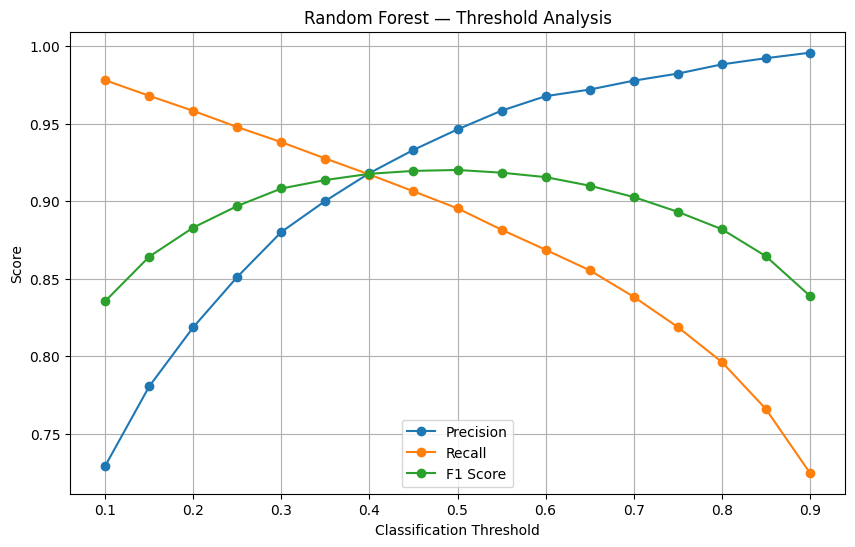

In [42]:
# ============================================================
# CELL 39 — THRESHOLD PERFORMANCE
# ============================================================

plt.figure(figsize=(10, 6))

plt.plot(
    threshold_df["Threshold"],
    threshold_df["Precision"],
    marker="o",
    label="Precision"
)

plt.plot(
    threshold_df["Threshold"],
    threshold_df["Recall"],
    marker="o",
    label="Recall"
)

plt.plot(
    threshold_df["Threshold"],
    threshold_df["F1"],
    marker="o",
    label="F1 Score"
)

plt.xlabel("Classification Threshold")
plt.ylabel("Score")
plt.title("Random Forest — Threshold Analysis")

plt.legend()
plt.grid(True)

plt.show()

In [43]:
# ============================================================
# CELL 40 — CALIBRATE RANDOM FOREST
# ============================================================

from sklearn.calibration import CalibratedClassifierCV

print("Calibrating Random Forest...")

calibrated_rf = CalibratedClassifierCV(
    rf_model,
    method="isotonic",
    cv=3
)

calibrated_rf.fit(
    X_train,
    y_train
)

print("Calibration completed.")

Calibrating Random Forest...
Calibration completed.


In [44]:
# ============================================================
# CELL 41 — CALIBRATED MODEL VALIDATION
# ============================================================

calibrated_val_probabilities = (
    calibrated_rf.predict_proba(X_val)[:, 1]
)

calibrated_val_predictions = (
    calibrated_val_probabilities >= 0.50
).astype(int)

cal_accuracy = accuracy_score(
    y_val,
    calibrated_val_predictions
)

cal_precision = precision_score(
    y_val,
    calibrated_val_predictions
)

cal_recall = recall_score(
    y_val,
    calibrated_val_predictions
)

cal_f1 = f1_score(
    y_val,
    calibrated_val_predictions
)

cal_roc_auc = roc_auc_score(
    y_val,
    calibrated_val_probabilities
)

cal_pr_auc = average_precision_score(
    y_val,
    calibrated_val_probabilities
)

print("Calibrated Random Forest")
print("=" * 50)

print(f"Accuracy : {cal_accuracy:.4f}")
print(f"Precision: {cal_precision:.4f}")
print(f"Recall   : {cal_recall:.4f}")
print(f"F1 Score : {cal_f1:.4f}")
print(f"ROC-AUC  : {cal_roc_auc:.4f}")
print(f"PR-AUC   : {cal_pr_auc:.4f}")

Calibrated Random Forest
Accuracy : 0.9208
Precision: 0.9568
Recall   : 0.8812
F1 Score : 0.9174
ROC-AUC  : 0.9728
PR-AUC   : 0.9780


In [45]:
# ============================================================
# CELL 42 — FINAL TEST EVALUATION
# ============================================================

print("Evaluating Random Forest on untouched test set...")

rf_test_predictions = rf_model.predict(X_test)

rf_test_probabilities = (
    rf_model.predict_proba(X_test)[:, 1]
)

test_accuracy = accuracy_score(
    y_test,
    rf_test_predictions
)

test_precision = precision_score(
    y_test,
    rf_test_predictions
)

test_recall = recall_score(
    y_test,
    rf_test_predictions
)

test_f1 = f1_score(
    y_test,
    rf_test_predictions
)

test_roc_auc = roc_auc_score(
    y_test,
    rf_test_probabilities
)

test_pr_auc = average_precision_score(
    y_test,
    rf_test_probabilities
)

print("\nFINAL RANDOM FOREST TEST RESULTS")
print("=" * 55)

print(f"Accuracy : {test_accuracy:.4f}")
print(f"Precision: {test_precision:.4f}")
print(f"Recall   : {test_recall:.4f}")
print(f"F1 Score : {test_f1:.4f}")
print(f"ROC-AUC  : {test_roc_auc:.4f}")
print(f"PR-AUC   : {test_pr_auc:.4f}")

Evaluating Random Forest on untouched test set...

FINAL RANDOM FOREST TEST RESULTS
Accuracy : 0.9249
Precision: 0.9423
Recall   : 0.9049
F1 Score : 0.9233
ROC-AUC  : 0.9753
PR-AUC   : 0.9799


In [46]:
# ============================================================
# CELL 43 — FINAL CLASSIFICATION REPORT
# ============================================================

print("FINAL TEST CLASSIFICATION REPORT")
print("=" * 55)

print(
    classification_report(
        y_test,
        rf_test_predictions,
        target_names=[
            "Legitimate",
            "Phishing"
        ],
        digits=4
    )
)

FINAL TEST CLASSIFICATION REPORT
              precision    recall  f1-score   support

  Legitimate     0.9088    0.9447    0.9264      7202
    Phishing     0.9423    0.9049    0.9233      7185

    accuracy                         0.9249     14387
   macro avg     0.9255    0.9248    0.9248     14387
weighted avg     0.9255    0.9249    0.9248     14387



In [47]:
# ============================================================
# CELL 43 — FINAL CLASSIFICATION REPORT
# ============================================================

print("FINAL TEST CLASSIFICATION REPORT")
print("=" * 55)

print(
    classification_report(
        y_test,
        rf_test_predictions,
        target_names=[
            "Legitimate",
            "Phishing"
        ],
        digits=4
    )
)

FINAL TEST CLASSIFICATION REPORT
              precision    recall  f1-score   support

  Legitimate     0.9088    0.9447    0.9264      7202
    Phishing     0.9423    0.9049    0.9233      7185

    accuracy                         0.9249     14387
   macro avg     0.9255    0.9248    0.9248     14387
weighted avg     0.9255    0.9249    0.9248     14387



In [48]:
# ============================================================
# CELL 45 — FINAL ERROR ANALYSIS
# ============================================================

# Create confusion matrix directly
test_cm = confusion_matrix(
    y_test,
    rf_test_predictions
)

tn, fp, fn, tp = test_cm.ravel()

false_positive_rate = fp / (fp + tn)

false_negative_rate = fn / (fn + tp)

print("FINAL ERROR ANALYSIS")
print("=" * 50)

print(f"True Negatives : {tn}")
print(f"False Positives: {fp}")
print(f"False Negatives: {fn}")
print(f"True Positives : {tp}")

print()

print(
    f"False Positive Rate: "
    f"{false_positive_rate:.4%}"
)

print(
    f"False Negative Rate: "
    f"{false_negative_rate:.4%}"
)

FINAL ERROR ANALYSIS
True Negatives : 6804
False Positives: 398
False Negatives: 683
True Positives : 6502

False Positive Rate: 5.5262%
False Negative Rate: 9.5059%


In [49]:
# ============================================================
# CELL 52 — PREDICT ENTIRE DATASET
# ============================================================

print("Predicting on complete dataset...")

all_predictions = rf_model.predict(X)

all_probabilities = rf_model.predict_proba(X)[:, 1]

all_correct = (
    all_predictions == y.values
)

print("Total URLs:", len(y))
print("Correct predictions:", all_correct.sum())
print("Incorrect predictions:", (~all_correct).sum())

overall_accuracy = (
    all_correct.mean() * 100
)

print(f"\nOverall dataset accuracy: {overall_accuracy:.2f}%")

Predicting on complete dataset...
Total URLs: 95911
Correct predictions: 93658
Incorrect predictions: 2253

Overall dataset accuracy: 97.65%


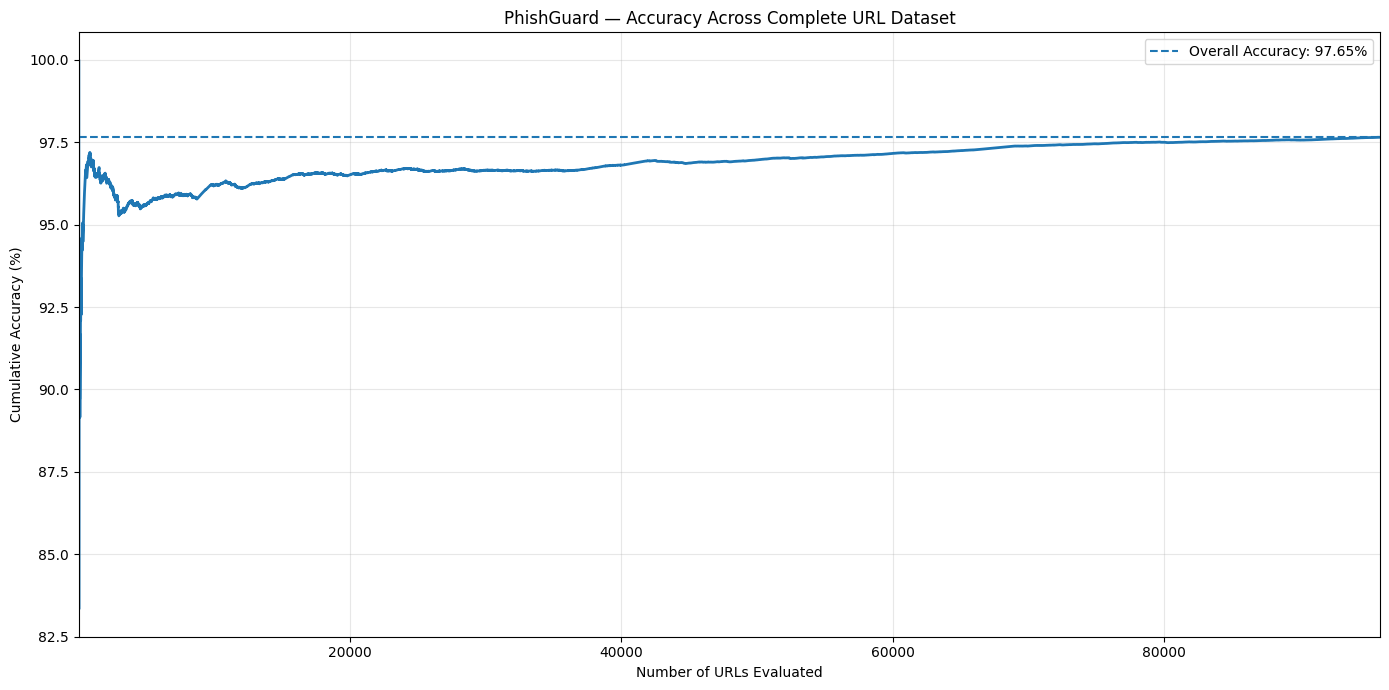

In [50]:
# ============================================================
# CELL 53 — ACCURACY ACROSS COMPLETE DATASET
# ============================================================

# Cumulative number of correct predictions
cumulative_correct = np.cumsum(all_correct)

# Number of URLs processed
num_urls = np.arange(
    1,
    len(y) + 1
)

# Cumulative accuracy
cumulative_accuracy_all = (
    cumulative_correct / num_urls
) * 100


plt.figure(figsize=(14, 7))

plt.plot(
    num_urls,
    cumulative_accuracy_all,
    linewidth=2
)

plt.axhline(
    y=overall_accuracy,
    linestyle="--",
    linewidth=1.5,
    label=f"Overall Accuracy: {overall_accuracy:.2f}%"
)

plt.xlabel("Number of URLs Evaluated")
plt.ylabel("Cumulative Accuracy (%)")

plt.title(
    "PhishGuard — Accuracy Across Complete URL Dataset"
)

plt.legend()

plt.grid(True, alpha=0.3)

plt.xlim(
    1,
    len(y)
)

plt.tight_layout()
plt.show()

In [51]:
# ============================================================
# CELL 54 — OUT-OF-FOLD PREDICTIONS
# ============================================================

from sklearn.model_selection import StratifiedKFold
from sklearn.base import clone

print("Starting 5-fold Out-of-Fold evaluation...")
print("Total URLs:", len(X))

skf = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

oof_predictions = np.zeros(len(X), dtype=int)
oof_probabilities = np.zeros(len(X), dtype=float)

for fold, (train_idx, val_idx) in enumerate(
    skf.split(X, y),
    start=1
):

    print(f"\nTraining Fold {fold}/5...")

    # Create a fresh model for this fold
    fold_model = RandomForestClassifier(
        n_estimators=300,
        max_depth=None,
        min_samples_split=2,
        min_samples_leaf=1,
        random_state=42 + fold,
        n_jobs=-1,
        class_weight="balanced"
    )

    # Train ONLY on this fold's training data
    fold_model.fit(
        X.iloc[train_idx],
        y.iloc[train_idx]
    )

    # Predict ONLY on unseen fold
    oof_predictions[val_idx] = fold_model.predict(
        X.iloc[val_idx]
    )

    oof_probabilities[val_idx] = (
        fold_model.predict_proba(
            X.iloc[val_idx]
        )[:, 1]
    )

    fold_accuracy = accuracy_score(
        y.iloc[val_idx],
        oof_predictions[val_idx]
    )

    print(
        f"Fold {fold} accuracy: "
        f"{fold_accuracy:.4f}"
    )

print("\nOOF evaluation completed.")

Starting 5-fold Out-of-Fold evaluation...
Total URLs: 95911

Training Fold 1/5...
Fold 1 accuracy: 0.9244

Training Fold 2/5...
Fold 2 accuracy: 0.9271

Training Fold 3/5...
Fold 3 accuracy: 0.9246

Training Fold 4/5...
Fold 4 accuracy: 0.9249

Training Fold 5/5...
Fold 5 accuracy: 0.9216

OOF evaluation completed.


In [52]:
# ============================================================
# CELL 55 — OVERALL OOF PERFORMANCE
# ============================================================

oof_accuracy = accuracy_score(
    y,
    oof_predictions
)

oof_precision = precision_score(
    y,
    oof_predictions
)

oof_recall = recall_score(
    y,
    oof_predictions
)

oof_f1 = f1_score(
    y,
    oof_predictions
)

oof_roc_auc = roc_auc_score(
    y,
    oof_probabilities
)

oof_pr_auc = average_precision_score(
    y,
    oof_probabilities
)

print("5-FOLD OUT-OF-FOLD RESULTS")
print("=" * 55)

print(f"Accuracy : {oof_accuracy:.4f}")
print(f"Precision: {oof_precision:.4f}")
print(f"Recall   : {oof_recall:.4f}")
print(f"F1 Score : {oof_f1:.4f}")
print(f"ROC-AUC  : {oof_roc_auc:.4f}")
print(f"PR-AUC   : {oof_pr_auc:.4f}")

5-FOLD OUT-OF-FOLD RESULTS
Accuracy : 0.9245
Precision: 0.9434
Recall   : 0.9031
F1 Score : 0.9228
ROC-AUC  : 0.9746
PR-AUC   : 0.9794


In [53]:
# ============================================================
# CELL 56 — OOF CLASSIFICATION REPORT
# ============================================================

print(
    classification_report(
        y,
        oof_predictions,
        target_names=[
            "Legitimate",
            "Phishing"
        ],
        digits=4
    )
)

              precision    recall  f1-score   support

  Legitimate     0.9072    0.9459    0.9262     48009
    Phishing     0.9434    0.9031    0.9228     47902

    accuracy                         0.9245     95911
   macro avg     0.9253    0.9245    0.9245     95911
weighted avg     0.9253    0.9245    0.9245     95911



In [54]:
# ============================================================
# CELL 57 — PREPARE OOF CUMULATIVE ACCURACY
# ============================================================

rng = np.random.RandomState(42)

random_order = rng.permutation(
    len(y)
)

ordered_correct = (
    oof_predictions[random_order]
    == y.values[random_order]
)

cumulative_correct_oof = np.cumsum(
    ordered_correct
)

num_urls_oof = np.arange(
    1,
    len(y) + 1
)

cumulative_accuracy_oof = (
    cumulative_correct_oof
    / num_urls_oof
) * 100

print("Total URLs evaluated:", len(y))

print(
    f"Final OOF accuracy: "
    f"{cumulative_accuracy_oof[-1]:.2f}%"
)

Total URLs evaluated: 95911
Final OOF accuracy: 92.45%


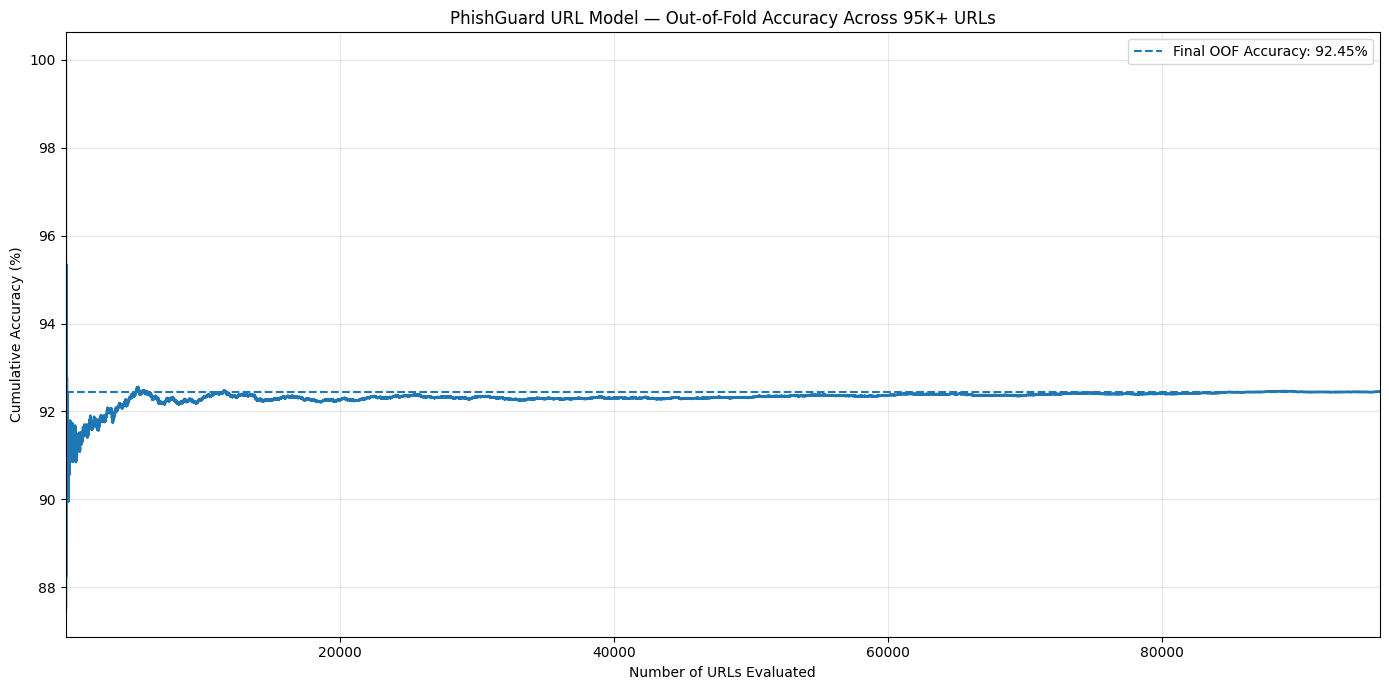

In [55]:
# ============================================================
# CELL 58 — OOF ACCURACY ACROSS ALL ~96K URLs
# ============================================================

plt.figure(figsize=(14, 7))

plt.plot(
    num_urls_oof,
    cumulative_accuracy_oof,
    linewidth=2
)

plt.axhline(
    y=oof_accuracy * 100,
    linestyle="--",
    linewidth=1.5,
    label=f"Final OOF Accuracy: {oof_accuracy * 100:.2f}%"
)

plt.xlabel(
    "Number of URLs Evaluated"
)

plt.ylabel(
    "Cumulative Accuracy (%)"
)

plt.title(
    "PhishGuard URL Model — "
    "Out-of-Fold Accuracy Across 95K+ URLs"
)

plt.legend()

plt.grid(
    True,
    alpha=0.3
)

plt.xlim(
    1,
    len(y)
)

plt.tight_layout()

plt.show()